# Implementing Monte Carlo Methods for Estimating Value Functions

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Monte Carlo methods for value estimation
- Implement first-visit and every-visit Monte Carlo
- Estimate state value functions from sampled episodes
- Compare first-visit and every-visit estimates on the same episodes
- Explain when Monte Carlo fits (episodic tasks) and why TD learning, covered next, updates earlier

## 🔗 Prerequisites

- ✅ Understanding of value functions (V(s), Q(s,a))
- ✅ Understanding of episodes and returns
- ✅ Python knowledge (functions, dictionaries, loops)
- ✅ NumPy, Matplotlib knowledge
- ✅ Basic RL concepts (states, actions, rewards, policies)

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 2**:
- Implementing Monte Carlo methods for estimating value functions

---

## Introduction

**Monte Carlo methods** learn value functions from experience (sample episodes). They don't require a model of the environment and use actual returns (sum of rewards) observed from episodes.

## Lesson Brief

This lesson explains how **Monte Carlo methods** estimate values from complete episodes.

Students will see how learning can happen from returns observed after an episode finishes, without needing a model of the environment.

Why this matters: Monte Carlo methods are an important stepping stone between dynamic programming and temporal-difference learning.

They also help students think carefully about what a return actually means.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **deeplizard - "Reinforcement Learning 5: Monte Carlo methods"**:
[Watch on YouTube](https://www.youtube.com/watch?v=4xfWzLmIccs)

Why this pick:
- focused teaching style.
- Explains episode returns and why Monte Carlo methods wait until trajectories finish.
- Good support for value estimation before TD methods enter the picture.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Return: total discounted reward from now onward.
- Episode-end update: learning after the full episode finishes.
- Sample average: averaging observed returns across episodes.
- Variance: instability in return estimates.
- First-visit vs every-visit: whether a state is updated once or multiple times per episode.

### Quick Check
- Why wait until the episode ends?
- Why are many episodes needed?
- How does this differ from TD methods?
- Why might Monte Carlo be simple but noisy?

### Common Mistakes
- Treating one episode as enough evidence.
- Expecting immediate updates.
- Ignoring high variance.
- Forgetting the difference between first-visit and every-visit updates.


## What this notebook should teach

This notebook is about learning from **complete episodes**.

By the end, you should be able to:

- compute returns from an episode
- explain first-visit vs every-visit Monte Carlo
- estimate state values from sampled episodes


## Monte Carlo in Plain Language

Monte Carlo methods answer a simple question:

`If I watch a full episode finish, what total return did this state really lead to?`

### Why do students often understand Monte Carlo first?

Because it uses a very direct learning story:

- run an episode
- compute the returns
- average what happened

There is no bootstrapping yet.
That makes the logic easier to trust at first.

### Then why not use Monte Carlo for everything?

Because it must wait until the episode ends.
That creates two practical problems:

- learning can be slower
- returns can have high variance across episodes

### First-visit vs every-visit

- **First-visit Monte Carlo** updates a state using only the first time it appears in an episode.
- **Every-visit Monte Carlo** updates a state every time it appears in an episode.

Both use sampled returns, but they organize the evidence slightly differently.

### Bridge to the next notebook

Monte Carlo is important because it teaches students what a return means.
The next step is TD learning, where we stop waiting for the full episode and start learning earlier from partial evidence.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
from collections import defaultdict
# Load a library so you can use its ready-made functions and types below.
import random

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nImplementing Monte Carlo Methods for Value Estimation")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


✅ Libraries imported!

Implementing Monte Carlo Methods for Value Estimation


## Part 1: Understanding Monte Carlo Methods


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Understanding Monte Carlo Methods")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
example_episode = [
    # Execute: ("A", 0),
    ("A", 0),
    # Execute: ("B", 0),
    ("B", 0),
    # Execute: ("C", 1),
    ("C", 1),
# Execute: ]
]
# Save a value in a name so the next lines can read it.
gamma = 0.9

# Another assignment—same idea: store a value for the lines below.
returns = []
# Another assignment—same idea: store a value for the lines below.
G = 0.0
# Start a loop: repeat the indented block once per item in the sequence.
for state, reward in reversed(example_episode):
    # Save a value in a name so the next lines can read it.
    G = reward + gamma * G
    # Execute: returns.insert(0, (state, G))
    returns.insert(0, (state, G))

# Show text or numbers in the cell output area under the code.
print("Example episode:", example_episode)
# Show text or numbers in the cell output area under the code.
print("Discount factor:", gamma)
# Show text or numbers in the cell output area under the code.
print("Returns from each state:")
# Start a loop: repeat the indented block once per item in the sequence.
for state, g in returns:
    # Show text or numbers in the cell output area under the code.
    print(f"  State {state}: return = {g:.3f}")


Part 1: Understanding Monte Carlo Methods
Example episode: [('A', 0), ('B', 0), ('C', 1)]
Discount factor: 0.9
Returns from each state:
  State A: return = 0.810
  State B: return = 0.900
  State C: return = 1.000


## Part 2: First-Visit Monte Carlo Implementation


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: First-Visit Monte Carlo Implementation")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
episodes = [
    # Execute: [("A", 0), ("B", 0), ("C", 1)],
    [("A", 0), ("B", 0), ("C", 1)],
    # Execute: [("A", 0), ("A", 0), ("C", 1)],
    [("A", 0), ("A", 0), ("C", 1)],
    # Execute: [("B", 0), ("C", 1)],
    [("B", 0), ("C", 1)],
# Execute: ]
]


# Function `first_visit_mc` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: episodes, gamma.
def first_visit_mc(episodes, gamma=0.9):
    # Save a value in a name so the next lines can read it.
    returns_by_state = defaultdict(list)
    # Start a loop: repeat the indented block once per item in the sequence.
    for episode in episodes:
        # Save a value in a name so the next lines can read it.
        visited = set()
        # Another assignment—same idea: store a value for the lines below.
        G = 0.0
        # Another assignment—same idea: store a value for the lines below.
        returns = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for state, reward in reversed(episode):
            # Save a value in a name so the next lines can read it.
            G = reward + gamma * G
            # Execute: returns.insert(0, (state, G))
            returns.insert(0, (state, G))
        # Start a loop: repeat the indented block once per item in the sequence.
        for state, G in returns:
            # If the condition is True, run the indented block under this line.
            if state not in visited:
                # Add one new item to the end of a list (the list grows in place).
                returns_by_state[state].append(G)
                # Execute: visited.add(state)
                visited.add(state)
    # Send a value back to whoever called this function.
    return {state: np.mean(values) for state, values in returns_by_state.items()}


# Save a value in a name so the next lines can read it.
fv_values = first_visit_mc(episodes)
# Show text or numbers in the cell output area under the code.
print("First-visit MC estimates:", {k: round(v, 3) for k, v in fv_values.items()})



Part 2: First-Visit Monte Carlo Implementation
First-visit MC estimates: {'A': np.float64(0.81), 'B': np.float64(0.9), 'C': np.float64(1.0)}


## Part 3: Every-Visit Monte Carlo Implementation


### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Every-Visit Monte Carlo Implementation")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


# Function `every_visit_mc` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: episodes, gamma.
def every_visit_mc(episodes, gamma=0.9):
    # Save a value in a name so the next lines can read it.
    returns_by_state = defaultdict(list)
    # Start a loop: repeat the indented block once per item in the sequence.
    for episode in episodes:
        # Save a value in a name so the next lines can read it.
        G = 0.0
        # Another assignment—same idea: store a value for the lines below.
        returns = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for state, reward in reversed(episode):
            # Save a value in a name so the next lines can read it.
            G = reward + gamma * G
            # Execute: returns.insert(0, (state, G))
            returns.insert(0, (state, G))
        # Start a loop: repeat the indented block once per item in the sequence.
        for state, G in returns:
            # Add one new item to the end of a list (the list grows in place).
            returns_by_state[state].append(G)
    # Send a value back to whoever called this function.
    return {state: np.mean(values) for state, values in returns_by_state.items()}


# Save a value in a name so the next lines can read it.
ev_values = every_visit_mc(episodes)
# Show text or numbers in the cell output area under the code.
print("Every-visit MC estimates:", {k: round(v, 3) for k, v in ev_values.items()})
# Show text or numbers in the cell output area under the code.
print("\nCheckpoint:")
# Show text or numbers in the cell output area under the code.
print("If a state appears multiple times in one episode, every-visit MC uses all of them,")
# Show text or numbers in the cell output area under the code.
print("while first-visit MC only uses the first occurrence.")



Part 3: Every-Visit Monte Carlo Implementation
Every-visit MC estimates: {'A': np.float64(0.84), 'B': np.float64(0.9), 'C': np.float64(1.0)}

Checkpoint:
If a state appears multiple times in one episode, every-visit MC uses all of them,
while first-visit MC only uses the first occurrence.


## Monte Carlo in context

Monte Carlo methods are especially natural when:

- the task is episodic
- you can wait until the episode ends
- you want to estimate values directly from sampled returns

They become less convenient when you need online updates before the episode finishes.

### Step Guide

**What this cell does:** Summarize or compare results (policies, returns, tables) for the lesson goal.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Tables, arrays, or comparison prints showing which policy or method wins.

**If you feel lost:** If output is empty, run the previous cells that define the data this cell consumes.


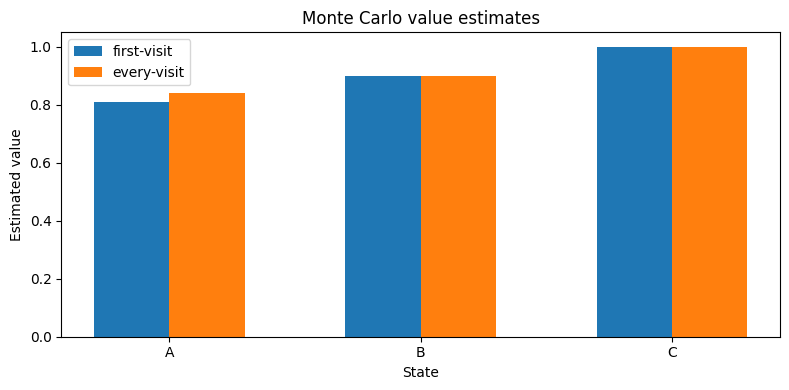

In [5]:
# Final computation: this cell usually summarizes the lesson, evaluates the result, or compares strategies.
# Pause here and ask what the numbers or tables say about the decision-making process.

# Save a value in a name so the next lines can read it.
states = sorted(set(list(fv_values.keys()) + list(ev_values.keys())))
# Another assignment—same idea: store a value for the lines below.
first_vals = [fv_values.get(state, np.nan) for state in states]
# Another assignment—same idea: store a value for the lines below.
every_vals = [ev_values.get(state, np.nan) for state in states]

# Call a Matplotlib pyplot helper (figure/axes/plot/show).
# Pedagogical note: if a state appears more than once in an episode, first-visit MC averages
# returns only from the first occurrence each episode, while every-visit MC averages returns
# from every occurrence. Bar heights can therefore differ for that state even with the same data.
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(8, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.bar(np.arange(len(states)) - 0.15, first_vals, width=0.3, label="first-visit")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.bar(np.arange(len(states)) + 0.15, every_vals, width=0.3, label="every-visit")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xticks(np.arange(len(states)), states)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("State")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Estimated value")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Monte Carlo value estimates")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()


## Summary

Monte Carlo methods estimate value from **complete sampled returns**.

### Main takeaways

- First-visit MC uses the first occurrence of a state in each episode.
- Every-visit MC uses all occurrences.
- Both methods are model-free.
- Both usually have higher variance than TD methods.

### Why this matters

Monte Carlo gives you a clean way to think about learning from complete experience
before moving to TD learning, which updates earlier and more often.

In [6]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


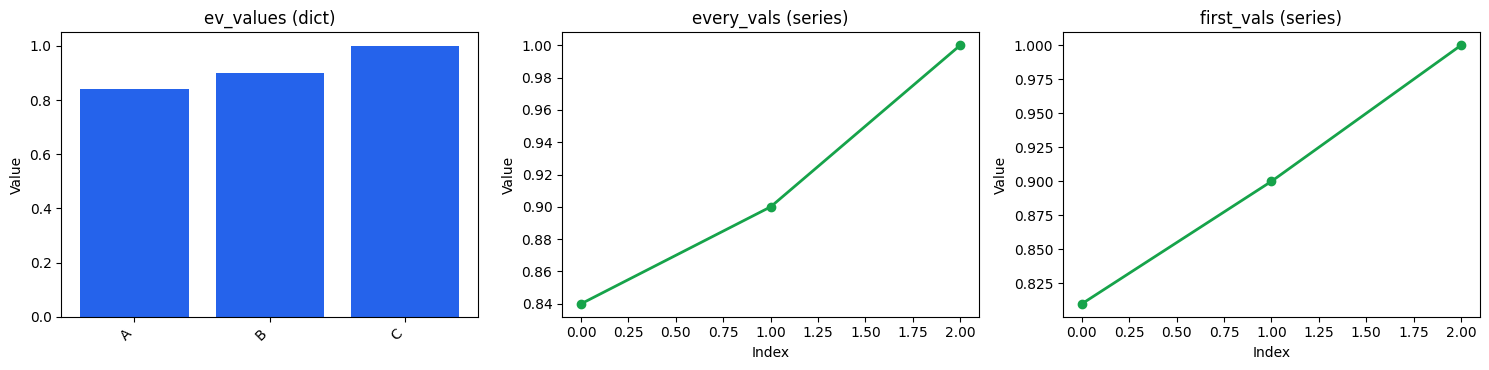

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Monte Carlo methods estimate value from complete episodes, which makes the logic intuitive but can increase variance.

**If students remember one idea:** Monte Carlo waits until the end of the episode, then uses the observed return as the learning signal.

**Quick check before moving on:**
- Can you explain why Monte Carlo needs complete returns before updating?
- Can you describe one advantage and one limitation of waiting until episode end?

**Bridge to the next step:** This leads naturally to temporal-difference learning, which updates earlier and more often.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=5 | term=True | trunc=False


objc[18733]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11236c138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1128689c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[18733]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11236c188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112868a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[18733]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11236bc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112868a68). T

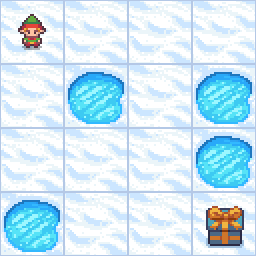

In [8]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
